In [22]:
# searchable parameters
# Naive = [0,1]
#   0: local_size_x_float: compute tile dimensions for float precision
#   1: local_size_x_double: compute tile dimensions for double precision
# CellList = [0]
#   0: local_size_x_float: compute tile dimensions for float precision
#   1: local_size_x_double: compute tile dimensions for double precision
#   2: max_cell_density: max number of particles supported per cell, multiple of average particle number per cell
#   3: particles_per_cell: dynamic number of cells based on number of particles
# Verlet = []
Naive = [0,1]
CellList = [0,1,2,3]
Verlet = []
Algorithms = [Naive, CellList, Verlet]
Algorithms_dict = {"Naive":0,"CellList":1,"Verlet":2}
Positions_dict = [
    {0:"local_size_x_float",1:"local_size_x_double"},
    {0:"local_size_x_float",1:"local_size_x_double",2:"max_cell_density",3:"particles_per_cell"},
    {}]
Algorithms

[[0, 1], [0, 1, 2, 3], []]

In [23]:
# find exisiting files
import os

for file in os.listdir("../results"):
    if file.startswith("param_search") and file.endswith(".json"):
        [_, _, file_Algorithm, file_Position, _] = file.rsplit("_")
        Algorithms[Algorithms_dict[file_Algorithm]].remove(int(file_Position))
Algorithms

[[], [0, 1, 2, 3], []]

In [24]:
# force running parameter search
force_all = False
force_Naive = []
force_CellList = []
force_Verlet = []

In [25]:
# skip running parameter search
skip_all = False
skip_Naive = []
skip_CellList = [0,1]
skip_Verlet = Verlet

In [26]:
# apply user specified targets adjustment
if force_all:
    Algorithms = [Naive, CellList, Verlet]
Algorithms[0] = list(set(Algorithms[0]) | set(force_Naive))
Algorithms[1] = list(set(Algorithms[1]) | set(force_CellList))
Algorithms[2] = list(set(Algorithms[2]) | set(force_Verlet))
Algorithms[0] = list(set(Algorithms[0]) - set(skip_Naive))
Algorithms[1] = list(set(Algorithms[1]) - set(skip_CellList))
Algorithms[2] = list(set(Algorithms[2]) - set(skip_Verlet))
Algorithms

[[], [2, 3], []]

In [27]:
# execute the benchmarks
import os
import subprocess
from pathlib import Path
import shutil

executable = str(Path("../build/src/nBodySimulation/acpp/param_search").resolve())
for it in range(0,3):
    for Position in Algorithms[it]:
        target = [executable, "--algorithm", list(Algorithms_dict.keys())[it], "--position", str(Position)]
        try:
            process = subprocess.Popen(target, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
            while True:
                output = process.stdout.readline()
                if output == '' and process.poll() is not None:
                    break
                if output:
                    print(output.strip())
            process.wait()
        except subprocess.CalledProcessError as e:
            print("param search failed: " + str(e))

for file in os.listdir():
    if file.startswith("param_search") and file.endswith(".json"):
        shutil.move(file, os.path.join("../results", os.path.basename(file)))

---------------------------------------------------------------------------------------------------
Benchmark                                         Time             CPU   Iterations UserCounters...
---------------------------------------------------------------------------------------------------
Param_Search-CellList-2-Float/4/100       993476856 ns    989809466 ns            1 force_update=315.211M position_update_reset=37.4625M velocity_update=8.97172M
Param_Search-CellList-2-Float/4/1000      881195323 ns    880849466 ns            1 force_update=296.44M position_update_reset=9.49308M velocity_update=9.008M
Param_Search-CellList-2-Float/4_BigO     937336089.50 (1)  935329466.00 (1)
Param_Search-CellList-2-Float/4_RMS               6 %             6 %
Param_Search-CellList-2-Float/8/100       907430255 ns    907090405 ns            1 force_update=307.044M position_update_reset=9.0568M velocity_update=8.74176M
Param_Search-CellList-2-Float/8/1000      893394580 ns    893165194 ns  

In [28]:
# fetch the data
import json
import pandas

data = []
for file in os.listdir("../results"):
    if not (file.startswith("param_search") and file.endswith(".json")):
        continue
    with open(os.path.join("../results", file), "r") as file:
        json_data = json.load(file)
        df = pandas.DataFrame(json_data["benchmarks"])
        df = df.dropna(subset=["iterations"])
        df = df[["name", "cpu_time", "time_unit", "force_update"]]
        name_size_split = df["name"].str.split("/", expand=True)
        details_split = name_size_split[0].str.split("-", expand=True)
        df["Parameter Value"] = name_size_split[1].astype(int)
        df["Problem Size"] = name_size_split[2].astype(int)
        df["Algorithm"] = details_split[1].astype(str)
        df["Parameter"] = details_split[2].astype(str)
        df["Precision"] = details_split[3].astype(str)

        df.rename(columns={
                "cpu_time": "CPU Time",
                "time_unit": "Time Unit",
                "force_update": "Force Time"
        }, inplace=True)

        df = df[["Algorithm", "Parameter", "Precision", "Parameter Value", "Problem Size", "CPU Time", "Time Unit", "Force Time"]]
        data.append(df)
data

[   Algorithm Parameter Precision  Parameter Value  Problem Size      CPU Time  \
 0   CellList         3     Float                4           100  9.863196e+08   
 1   CellList         3     Float                4          1000  7.224859e+08   
 4   CellList         3     Float                8           100  9.015349e+08   
 5   CellList         3     Float                8          1000  8.805988e+08   
 8   CellList         3     Float               16           100  7.213890e+08   
 9   CellList         3     Float               16          1000  2.349048e+09   
 12  CellList         3     Float               32           100  7.148284e+08   
 13  CellList         3     Float               32          1000  2.349645e+09   
 16  CellList         3     Float               64           100  7.224732e+08   
 17  CellList         3     Float               64          1000  5.758299e+09   
 20  CellList         3     Float              128           100  7.313417e+08   
 21  CellList   

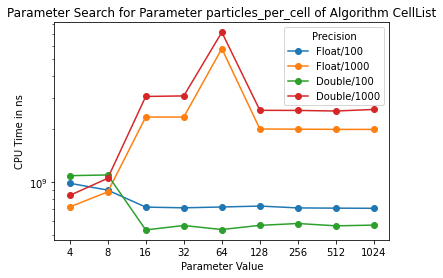

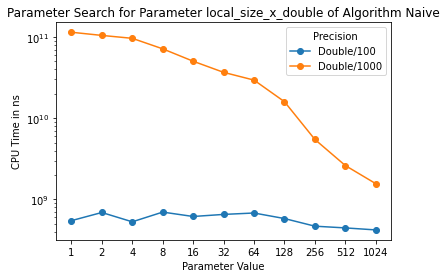

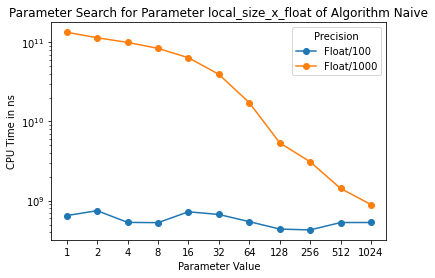

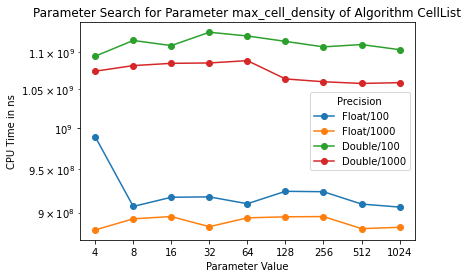

In [29]:
# display the data
import matplotlib.pyplot as plt

for df in data:
    for precision in df["Precision"].unique():
        for problem_size in df["Problem Size"].unique():
            subset = df[df["Problem Size"] == problem_size]
            subset = subset[subset["Precision"] == precision]
            label = precision + "/" + str(problem_size)
            plt.plot(subset["Parameter Value"].astype("str"), subset["CPU Time"], marker='o', label=label)
    plt.yscale("log")
    plt.xlabel("Parameter Value")
    plt.ylabel("CPU Time in "+df["Time Unit"][0])
    parameter_name = Positions_dict[Algorithms_dict[df["Algorithm"][0]]][int(df["Parameter"][0])]
    plt.title("Parameter Search for Parameter "+parameter_name+" of Algorithm "+df["Algorithm"][0])
    plt.legend(title="Precision")
    plt.show()